In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. FIND THE CORRECT FILE
# If your file is named something else, change 'training.csv' below
file_path = '../data/raw/data.csv' 

df = pd.read_csv(file_path)
print(f"Dataset loaded! Shape: {df.shape}")
print("Columns:", df.columns.tolist())
df.head()

Dataset loaded! Shape: (79099, 16)
Columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256.0,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000.0,2018-11-15T02:18:49Z,2.0,0.0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256.0,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20.0,2018-11-15T02:19:08Z,2.0,0.0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256.0,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500.0,2018-11-15T02:44:21Z,2.0,0.0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256.0,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800.0,2018-11-15T03:32:55Z,2.0,0.0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256.0,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644.0,2018-11-15T03:34:21Z,2.0,0.0


In [9]:
# Summary statistics
print(df.describe())

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

       CountryCode        Amount         Value  PricingStrategy   FraudResult
count      79098.0  7.909800e+04  7.909800e+04     79098.000000  79098.000000
mean         256.0  5.156739e+03  8.756396e+03         2.269172      0.001757
std            0.0  8.310834e+04  8.283878e+04         0.751515      0.041884
min          256.0 -1.000000e+06  2.000000e+00         0.000000      0.000000
25%          256.0 -5.000000e+01  2.500000e+02         2.000000      0.000000
50%          256.0  1.000000e+03  1.000000e+03         2.000000      0.000000
75%          256.0  2.000000e+03  5.000000e+03         2.000000      0.000000
max          256.0  8.600000e+06  8.600000e+06         4.000000      1.000000

Missing values per column:
TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            1
CountryCode             1
ProviderId              1
ProductId               1
ProductCategory         1
ChannelId 

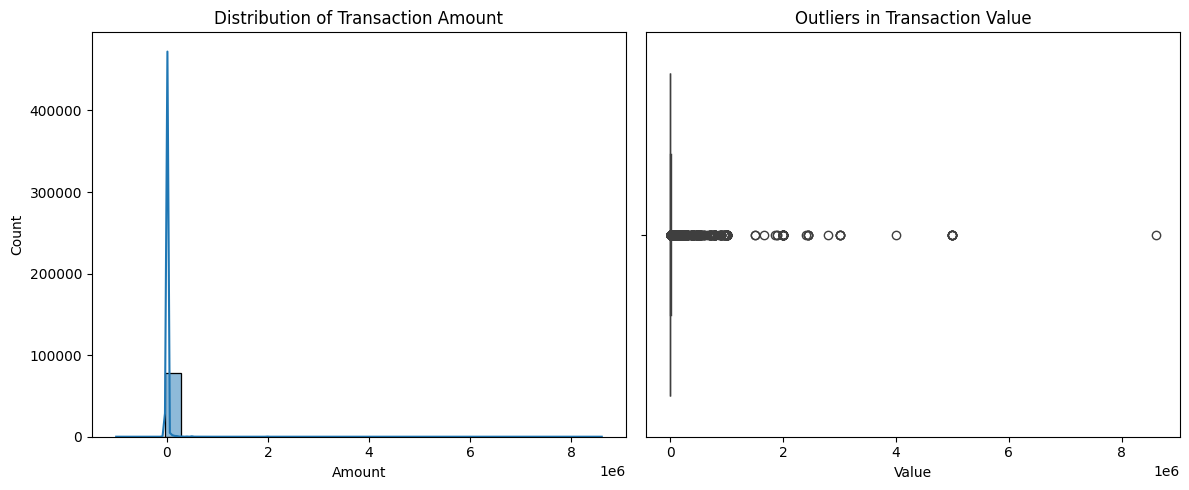

In [10]:
plt.figure(figsize=(12, 5))

# Plot Amount Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title('Distribution of Transaction Amount')

# Plot Value Distribution (Absolute value)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Value'])
plt.title('Outliers in Transaction Value')

plt.tight_layout()
plt.show()

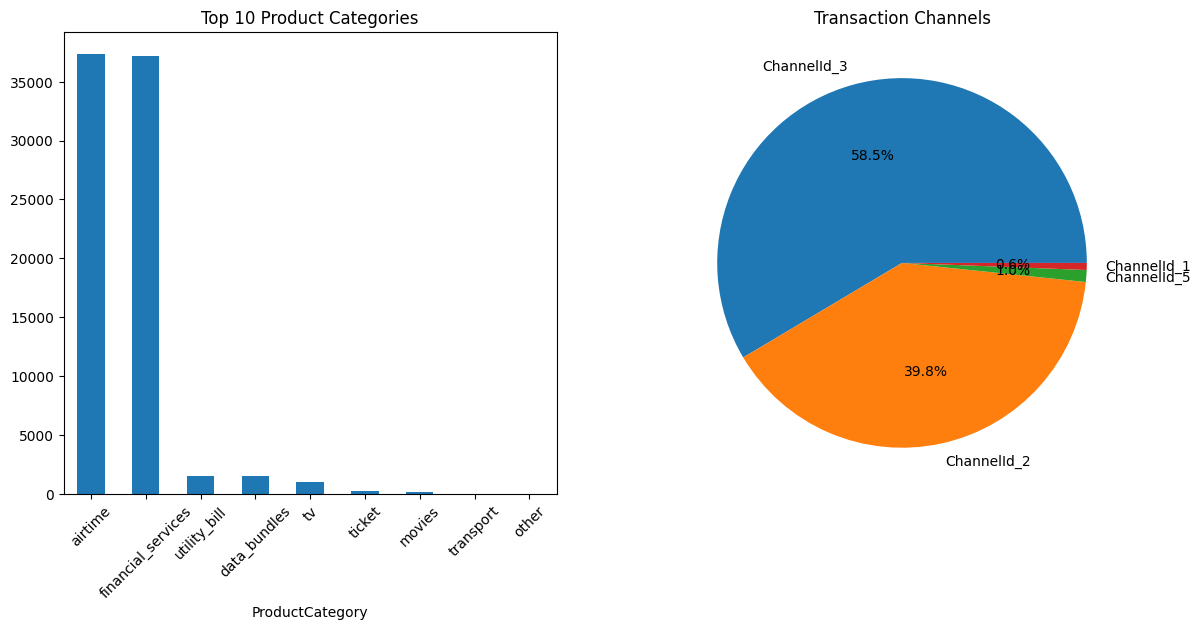

In [11]:
plt.figure(figsize=(14, 6))

# Top Product Categories
plt.subplot(1, 2, 1)
df['ProductCategory'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Product Categories')
plt.xticks(rotation=45)

# Channel Usage
plt.subplot(1, 2, 2)
df['ChannelId'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Transaction Channels')

plt.show()

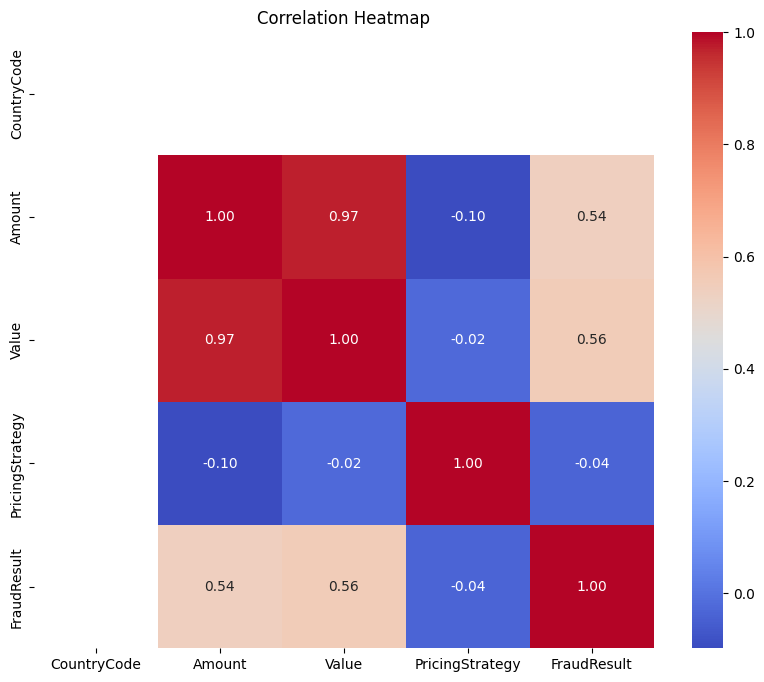

In [12]:
plt.figure(figsize=(10, 8))
# Only numeric columns
numeric_cols = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

Task 2 - Exploratory Data Analysis Insights
High Feature Correlation: There is a near-perfect correlation (0.97) between Amount and Value. This is expected as Value represents the absolute amount. Interestingly, FraudResult shows a moderate correlation (0.54) with transaction size, suggesting higher value transactions may carry higher risk.
Dominant Categories: The platform is primarily used for 'Airtime' and 'Financial Services'. These two categories account for the vast majority of transaction volume, while others like 'Movies' or 'Transport' are minimal.
Channel Preference: Users mainly transact through two channels: ChannelId_3 (58.5%) and ChannelId_2 (39.8%). This indicates a concentrated user base on specific platforms (likely Mobile and Web).
Extreme Outliers: Both the distribution plot and boxplot show extreme right-skewness. While most transactions are small, there are significant outliers reaching over 8 million in value. These will need to be handled carefully during the feature engineering phase to prevent model distortion.
Data Consistency: CountryCode shows zero variance in the heatmap, suggesting the dataset is currently focused on a single country/market.